<!-- # Analyze GAM models results -->

# Evaluate model's capacity to predict a transition

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

### Load Models

In [2]:
# ============================================================
# Constants / conventions
# ============================================================

STATE_LABELS = {0: "A", 1: "D", 2: "O"}
VALID_TRANSITIONS = [
    (0, 0), (0, 1), (0, 2),   # A -> A,D,O
    (1, 0), (1, 1),           # D -> A,D
    (2, 0), (2, 2),           # O -> A,O
]

PROB_COLS = ["pAA", "pAD", "pAO", "pDA", "pDD", "pDO", "pOA", "pOD", "pOO"]


In [3]:
# ============================================================
# Loading / standardizing model outputs
# ============================================================

def _add_full_probability_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Standardize a model-result dataframe so it always has all 9 transition columns.
    Convention:
      - from A: pAA = 1 - pAD - pAO
      - from D: pDD = 1 - pDA, pDO = 0
      - from O: pOO = 1 - pOA, pOD = 0
    """
    out = df.copy()

    # Ensure float type where relevant
    for c in ["pAD", "pAO", "pDA", "pOA"]:
        if c in out.columns:
            out[c] = out[c].astype(float)

    out["pAA"] = 1.0 - out["pAD"] - out["pAO"]
    out["pDD"] = 1.0 - out["pDA"]
    out["pOO"] = 1.0 - out["pOA"]
    out["pDO"] = 0.0
    out["pOD"] = 0.0

    # Clip tiny numerical violations
    for c in PROB_COLS:
        out[c] = np.clip(out[c], 0.0, 1.0)

    # Optional: row-wise renormalization per initial state for numerical safety
    maskA = out["Initial_gen_state"] == 0
    maskD = out["Initial_gen_state"] == 1
    maskO = out["Initial_gen_state"] == 2

    if maskA.any():
        s = out.loc[maskA, ["pAA", "pAD", "pAO"]].sum(axis=1)
        out.loc[maskA, ["pAA", "pAD", "pAO"]] = out.loc[maskA, ["pAA", "pAD", "pAO"]].div(s, axis=0)

    if maskD.any():
        s = out.loc[maskD, ["pDA", "pDD", "pDO"]].sum(axis=1)
        out.loc[maskD, ["pDA", "pDD", "pDO"]] = out.loc[maskD, ["pDA", "pDD", "pDO"]].div(s, axis=0)

    if maskO.any():
        s = out.loc[maskO, ["pOA", "pOD", "pOO"]].sum(axis=1)
        out.loc[maskO, ["pOA", "pOD", "pOO"]] = out.loc[maskO, ["pOA", "pOD", "pOO"]].div(s, axis=0)

    return out


def _transition_probability_for_realized_label(df: pd.DataFrame) -> pd.Series:
    """
    Return probability assigned to the realized transition in each row.
    """
    p_real = np.full(len(df), np.nan, dtype=float)

    # A -> *
    mask = (df["Initial_gen_state"] == 0) & (df["Final_gen_state"] == 0)
    p_real[mask] = df.loc[mask, "pAA"]

    mask = (df["Initial_gen_state"] == 0) & (df["Final_gen_state"] == 1)
    p_real[mask] = df.loc[mask, "pAD"]

    mask = (df["Initial_gen_state"] == 0) & (df["Final_gen_state"] == 2)
    p_real[mask] = df.loc[mask, "pAO"]

    # D -> *
    mask = (df["Initial_gen_state"] == 1) & (df["Final_gen_state"] == 0)
    p_real[mask] = df.loc[mask, "pDA"]

    mask = (df["Initial_gen_state"] == 1) & (df["Final_gen_state"] == 1)
    p_real[mask] = df.loc[mask, "pDD"]

    # O -> *
    mask = (df["Initial_gen_state"] == 2) & (df["Final_gen_state"] == 0)
    p_real[mask] = df.loc[mask, "pOA"]

    mask = (df["Initial_gen_state"] == 2) & (df["Final_gen_state"] == 2)
    p_real[mask] = df.loc[mask, "pOO"]

    return pd.Series(p_real, index=df.index, name="p_realized")


def load_feature_based_model_csv(path: str | Path) -> pd.DataFrame:
    """
    Load one feature-based model result csv.
    Expected columns:
      Datetime_UTC, State, Stress, Initial_gen_state, Final_gen_state,
      Data_weight, pAD, pAO, pDA, pOA, ...
    """
    df = pd.read_csv(path, parse_dates=["Datetime_UTC"])
    df = _add_full_probability_columns(df)
    df["p_realized"] = _transition_probability_for_realized_label(df)
    return df


def load_naive_model(path_naive: str | Path, reference_test_df: pd.DataFrame) -> pd.DataFrame:
    """
    Expand naive one-row-per-state model onto the reference test set.
    Naive csv columns:
      State, pAA, pAD, pAO, pDA, pDD, pOA, pOO
    """
    naive = pd.read_csv(path_naive)

    # add forbidden transitions explicitly
    if "pDO" not in naive.columns:
        naive["pDO"] = 0.0
    if "pOD" not in naive.columns:
        naive["pOD"] = 0.0

    cols_needed = ["State"] + PROB_COLS
    naive = naive[cols_needed].copy()

    # Merge naive probabilities onto the reference test rows
    out = reference_test_df[
        ["Datetime_UTC", "State", "Stress", "Initial_gen_state", "Final_gen_state", "Data_weight"]
    ].copy()

    out = out.merge(naive, on="State", how="left", validate="many_to_one")
    out["p_realized"] = _transition_probability_for_realized_label(out)
    return out


def load_all_models(path_naive: str | Path, paths_models: dict[str, str | Path], reference_model_name: str) -> dict[str, pd.DataFrame]:
    """
    Load all models into a common dictionary.
    Uses one feature-based model as reference for the naive expansion and stress bins.
    """
    model_results = {}

    # load feature-based models
    for model_name, path in paths_models.items():
        model_results[model_name] = load_feature_based_model_csv(path)

    if reference_model_name not in model_results:
        raise ValueError(f"reference_model_name={reference_model_name} not found in paths_models")

    # expand naive on the reference test set
    model_results["Naive"] = load_naive_model(path_naive, model_results[reference_model_name])

    return model_results

### Stress bins

In [4]:
def compute_stress_bin_edges(reference_df: pd.DataFrame) -> dict[str, float]:
    """
    Compute the 50%, 90%, 99% quantiles from the SMC model stress column.
    """
    stress = reference_df["Stress"].to_numpy(dtype=float)
    q50, q90, q99 = np.quantile(stress, [0.50, 0.90, 0.99])
    return {"q50": q50, "q90": q90, "q99": q99}


def assign_stress_bin(df: pd.DataFrame, edges: dict[str, float]) -> pd.DataFrame:
    out = df.copy()
    q50, q90, q99 = edges["q50"], edges["q90"], edges["q99"]

    conds = [
        out["Stress"] < q50,
        (out["Stress"] >= q50) & (out["Stress"] < q90),
        (out["Stress"] >= q90) & (out["Stress"] < q99),
        out["Stress"] >= q99,
    ]
    labels = ["Low", "Medium", "High", "Very High"]
    out["Stress_bin"] = np.select(conds, labels, default="Missing")
    return out

## Evaluation metrics

### NLL

In [5]:
def weighted_nll(p: np.ndarray, w: np.ndarray, eps: float = 1e-12) -> float:
    p = np.clip(np.asarray(p, dtype=float), eps, 1.0)
    w = np.asarray(w, dtype=float)

    good = np.isfinite(p) & np.isfinite(w) & (w > 0)
    if not np.any(good):
        return np.nan

    return float(-np.sum(w[good] * np.log(p[good])) / np.sum(w[good]))


def compute_nll_results(model_results: dict[str, pd.DataFrame]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Returns:
      nll_by_bin_df: columns [model, Stress_bin, NLL]
      nll_overall_df: columns [model, NLL]
    """
    rows_bin = []
    rows_all = []

    stress_order = ["Low", "Medium", "High", "Very High"]

    for model_name, df in model_results.items():
        # per stress bin
        for sb in stress_order:
            sub = df.loc[df["Stress_bin"] == sb]
            nll = weighted_nll(sub["p_realized"].values, sub["Data_weight"].values)
            rows_bin.append({"model": model_name, "Stress_bin": sb, "NLL": nll})

        # overall
        nll_all = weighted_nll(df["p_realized"].values, df["Data_weight"].values)
        rows_all.append({"model": model_name, "NLL": nll_all})

    nll_by_bin_df = pd.DataFrame(rows_bin)
    nll_overall_df = pd.DataFrame(rows_all)

    return nll_by_bin_df, nll_overall_df

### ECE

In [6]:
def _transition_col(i: int, j: int) -> str:
    return f"p{STATE_LABELS[i]}{STATE_LABELS[j]}"


def ece_equal_mass_bins(p, y, w, n_bins=10):
    """
    Weighted ECE using approximately equal-mass bins in p.
    Returns:
      ece_overall, bin_table
    """
    p = np.asarray(p, dtype=float)
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)

    good = np.isfinite(p) & np.isfinite(y) & np.isfinite(w) & (w > 0)
    p, y, w = p[good], y[good], w[good]

    if len(p) == 0:
        return np.nan, pd.DataFrame(columns=["bin", "p_mean", "y_mean", "weight", "ece_bin"])

    # sort by predicted probability
    order = np.argsort(p)
    p, y, w = p[order], y[order], w[order]

    cum_w = np.cumsum(w)
    total_w = cum_w[-1]
    targets = np.linspace(0, total_w, n_bins + 1)

    rows = []
    start = 0
    for b in range(n_bins):
        left_w = targets[b]
        right_w = targets[b + 1]

        # right boundary index
        end = np.searchsorted(cum_w, right_w, side="right")
        if end <= start:
            continue

        pb = p[start:end]
        yb = y[start:end]
        wb = w[start:end]

        wsum = wb.sum()
        p_mean = np.average(pb, weights=wb)
        y_mean = np.average(yb, weights=wb)
        ece_bin = abs(p_mean - y_mean)

        rows.append({
            "bin": b,
            "p_mean": p_mean,
            "y_mean": y_mean,
            "weight": wsum,
            "ece_bin": ece_bin,
        })

        start = end

    bin_table = pd.DataFrame(rows)
    if bin_table.empty:
        return np.nan, bin_table

    ece = np.sum(bin_table["weight"] * bin_table["ece_bin"]) / np.sum(bin_table["weight"])
    return float(ece), bin_table


def compute_ece_results(model_results: dict[str, pd.DataFrame], n_bins: int = 10) -> tuple[pd.DataFrame, dict]:
    """
    Returns:
      ece_df: tidy dataframe with columns
        [model, initial_state, final_state, transition, ECE, mean_occurrence]
      ece_details: nested dict with the bin tables if you want calibration plots later
    """
    rows = []
    details = {}

    for model_name, df in model_results.items():
        details[model_name] = {}

        for i, j in VALID_TRANSITIONS:
            pcol = _transition_col(i, j)

            sub = df.loc[df["Initial_gen_state"] == i].copy()
            if sub.empty:
                continue

            y = (sub["Final_gen_state"].to_numpy() == j).astype(float)
            p = sub[pcol].to_numpy(dtype=float)
            w = sub["Data_weight"].to_numpy(dtype=float)

            ece, bin_table = ece_equal_mass_bins(p, y, w, n_bins=n_bins)
            y_bar = np.average(y, weights=w) if np.sum(w) > 0 else np.nan

            rows.append({
                "model": model_name,
                "initial_state": i,
                "final_state": j,
                "transition": f"{STATE_LABELS[i]}→{STATE_LABELS[j]}",
                "ECE": ece,
                "mean_occurrence": y_bar,
            })

            details[model_name][(i, j)] = bin_table

    ece_df = pd.DataFrame(rows)
    return ece_df, details

## Compute metrics

In [7]:
def evaluate_transition_models(
    path_naive: str | Path,
    paths_models: dict[str, str | Path],
    reference_model_name: str = "SMC",
    n_bins_ece: int = 10,
):
    # Load everything
    print("Loading models...")
    model_results = load_all_models(
        path_naive=path_naive,
        paths_models=paths_models,
        reference_model_name=reference_model_name,
    )

    # Stress bins from the reference SMC model
    print("Computing and assigning stress bins...")
    edges = compute_stress_bin_edges(model_results[reference_model_name])

    # Apply same bins to every model
    for name in list(model_results.keys()):
        model_results[name] = assign_stress_bin(model_results[name], edges)

    # Metrics
    print("Computing NLL...")
    nll_by_bin_df, nll_overall_df = compute_nll_results(model_results)
    print("Computing ECE...")
    ece_df, ece_details = compute_ece_results(model_results, n_bins=n_bins_ece)

    return {
        "model_results": model_results,
        "stress_edges": edges,
        "nll_by_bin": nll_by_bin_df,
        "nll_overall": nll_overall_df,
        "ece": ece_df,
        "ece_details": ece_details,
    }

In [ ]:
path_naive = '/Users/malo/MIT Dropbox/Malo Lahogue/Research/Generator-outage-probability/Results/Transition_models/Naive/naive_model_results.csv'

paths_models = {
    'Semi-Markov': '/Users/malo/MIT Dropbox/Malo Lahogue/Research/Generator-outage-probability/Results/Transition_models/GAMS/SMC/GAM__SMC_fullH_GAM__results_test_ALABAMA.csv',
    'Semi-Markov_S': '/Users/malo/MIT Dropbox/Malo Lahogue/Research/Generator-outage-probability/Results/Transition_models/GAMS/SMC_S/GAM__SMC_fullH_simple_GAM__results_test_ALABAMA.csv',
    'Markov': '/Users/malo/MIT Dropbox/Malo Lahogue/Research/Generator-outage-probability/Results/Transition_models/GAMS/MC/GAM__MC_fullH_GAM__results_test_ALABAMA-2.csv',
    'Markov_S': '/Users/malo/MIT Dropbox/Malo Lahogue/Research/Generator-outage-probability/Results/Transition_models/GAMS/MC_S/GAM__MC_fullH_simple_GAM__results_test_ALABAMA-2.csv',
    'Logistic Regression': '/Users/malo/MIT Dropbox/Malo Lahogue/Research/Generator-outage-probability/Results/Transition_models/Logistic_Regression/GAM_LogisticReg_results_test_ALABAMA-4.csv',
    'Logistic Regression_S': '/Users/malo/MIT Dropbox/Malo Lahogue/Research/Generator-outage-probability/Results/Transition_models/Logistic_Regression_S/GAM_LogisticReg_results_test_ALABAMA-5.csv',
    'AS': '/Users/malo/MIT Dropbox/Malo Lahogue/Research/Generator-outage-probability/Results/Transition_models/GAMS/AS/GAM__AS_fullH_GAM__results_test_ALABAMA-2.csv',
    'AS_S': '/Users/malo/MIT Dropbox/Malo Lahogue/Research/Generator-outage-probability/Results/Transition_models/GAMS/AS_S/GAM__AS_fullH_simple_GAM__results_test_ALABAMA.csv'
}

In [9]:
res = evaluate_transition_models(
    path_naive=path_naive,
    paths_models=paths_models,
    # reference_model_name="Semi-Markov",
    reference_model_name="Semi-Markov_S",
    n_bins_ece=10,
)

Loading models...
Computing and assigning stress bins...
Computing NLL...
Computing ECE...


In [10]:
model_results = res["model_results"]
stress_edges = res["stress_edges"]
nll_by_bin_df = res["nll_by_bin"]
nll_overall_df = res["nll_overall"]
ece_df = res["ece"]
ece_details = res["ece_details"]

# Plots

In [11]:
def plot_nll_summary(
    nll_by_bin_df: pd.DataFrame,
    nll_overall_df: pd.DataFrame,
    model_order=None,
    stress_order=("Low", "Medium", "High", "Very High"),
    model_colors=None,
    figsize=(14, 6),
    print_label=True,
):
    if model_colors is None:
        model_colors = {}

    if model_order is None:
        model_order = list(nll_overall_df["model"].unique())

    # Pivot per-stress-bin
    piv = (
        nll_by_bin_df
        .pivot(index="Stress_bin", columns="model", values="NLL")
        .reindex(stress_order)
    )

    overall = (
        nll_overall_df
        .set_index("model")["NLL"]
        .reindex(model_order)
    )

    fig = plt.figure(figsize=figsize)
    gs = GridSpec(1, 2, width_ratios=[3.2, 1.2], wspace=0.25)
    axL = fig.add_subplot(gs[0, 0])
    axR = fig.add_subplot(gs[0, 1], sharey=axL)

    # hide y ticks on right
    axR.tick_params(axis="y", which="both", left=False, labelleft=False)

    # ---- Left: per stress bin ----
    x = np.arange(len(stress_order))
    k = len(model_order)
    bar_width = 0.8 / max(k, 1)
    offsets = (np.arange(k) - (k - 1) / 2.0) * bar_width

    for i, model in enumerate(model_order):
        vals = piv[model].values if model in piv.columns else np.full(len(stress_order), np.nan)
        axL.bar(
            x + offsets[i],
            vals,
            width=bar_width,
            color=model_colors.get(model, None),
            alpha=0.9,
            label=model,
        )
        if print_label:
            for xi, yi in zip(x + offsets[i], vals):
                if np.isfinite(yi):
                    axL.text(
                        xi, yi,
                        f"{yi:.2e}",
                        ha="center",
                        va="bottom",
                        fontsize=8,
                        rotation=90,
                    )

    axL.set_xticks(x)
    axL.set_xticklabels(stress_order)
    axL.set_ylabel("Negative Log-Likelihood")
    axL.set_title("Per-stress-bin")
    axL.grid(True, axis="y", alpha=0.25)
    axL.spines["top"].set_visible(False)
    axL.spines["right"].set_visible(False)

    # ---- Right: overall ----
    xr = np.arange(len(model_order))
    vals = overall.values
    axR.bar(
        xr,
        vals,
        width=0.7,
        color=[model_colors.get(m, None) for m in model_order],
        alpha=0.9,
    )

    if print_label:
        for xi, yi in zip(xr, vals):
            if np.isfinite(yi):
                axR.text(
                    xi, yi,
                    f"{yi:.2e}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    rotation=90,
                )

    axR.set_xticks(xr)
    axR.set_xticklabels(model_order, rotation=45, ha="right")
    axR.set_title("Overall")
    axR.grid(True, axis="y", alpha=0.25)
    axR.spines["top"].set_visible(False)
    axR.spines["right"].set_visible(False)

    # star best (lowest NLL) per stress bin
    star_handle = Line2D(
        [0], [0],
        marker="*",
        linestyle="None",
        markersize=12,
        markerfacecolor="black",
        markeredgecolor="black",
        label="Best model"
    )

    star_offset = 0.1*np.max([np.nanmax(piv.values), np.nanmax(overall.values)])
    for b, sb in enumerate(stress_order):
        vals_b = np.array([piv.loc[sb, m] if m in piv.columns else np.nan for m in model_order], dtype=float)
        if np.any(np.isfinite(vals_b)):
            best_i = int(np.nanargmin(vals_b))
            axL.text(
                x[b] + offsets[best_i], vals_b[best_i]-star_offset,
                "★", ha="center", va="bottom", fontsize=14
            )

    if np.any(np.isfinite(vals)):
        best_i = int(np.nanargmin(vals))
        axR.text(
            xr[best_i], vals[best_i]-star_offset,
            "★", ha="center", va="bottom", fontsize=14
        )

    axL.set_ylim(0, np.max([np.nanmax(piv.values), np.nanmax(overall.values)])*1.2)

    handles, labels = axL.get_legend_handles_labels()
    handles.append(star_handle)
    labels.append("Best model")
    axL.legend(handles, labels, title="Model", frameon=True, loc="upper left", ncol=2)

    # fig.suptitle("Transition prediction performance: NLL per stress bin and overall", y=1.02, fontsize=14)
    fig.suptitle("Negative Log Likelihood per stress bin and overall", y=1.02, fontsize=20)
    
    plt.show()

In [12]:
def plot_ece_matrix(
    ece_df: pd.DataFrame,
    model_order=None,
    model_colors=None,
    figsize=(13, 11),
    y_axis_log_scale=True,
):
    if model_colors is None:
        model_colors = {}

    if model_order is None:
        model_order = list(ece_df["model"].unique())

    transitions = [
        (0, 0), (0, 1), (0, 2),
        (1, 0), (1, 1),
        (2, 0), (2, 2),
    ]

    state_idx2str = {0: "A", 1: "D", 2: "O"}

    fig, axs = plt.subplots(3, 3, figsize=figsize, sharey=True)

    # blank impossible transitions
    impossible = {(1, 2), (2, 1)}

    legend_handles = [
        Line2D([0], [0], marker='s', linestyle='None',
               color=model_colors.get(m, 'gray'),
               markerfacecolor=model_colors.get(m, 'gray'),
               markersize=8, label=m)
        for m in model_order
    ]
    ref_handle = Line2D([0], [0], color='black', linewidth=2, label='Mean transition occurrence')
    star_handle = Line2D([0], [0], marker='*', linestyle='None', color='black', markersize=10, label='Best model')

    for i in [0, 1, 2]:
        for j in [0, 1, 2]:
            ax = axs[i, j]

            if (i, j) in impossible:
                ax.set_axis_off()
                continue

            sub = ece_df[(ece_df["initial_state"] == i) & (ece_df["final_state"] == j)].copy()
            if sub.empty:
                ax.set_axis_off()
                continue

            sub = sub.set_index("model").reindex(model_order).reset_index()

            x = np.arange(len(model_order))
            y = sub["ECE"].to_numpy(dtype=float)
            ybar = sub["mean_occurrence"].dropna()
            ref = float(ybar.iloc[0]) if len(ybar) > 0 else np.nan

            bars = ax.bar(
                x, y,
                color=[model_colors.get(m, "gray") for m in sub["model"]],
                alpha=0.85,
                width=0.65,
            )

            if np.isfinite(ref):
                ax.axhline(ref, color="black", linewidth=2)
                ax.text(
                    0.98, ref,
                    rf"$\bar{{y}}={ref:.2e}$",
                    transform=ax.get_yaxis_transform(),
                    ha="right", va="bottom",
                    fontsize=9,
                )

            # best = lowest ECE
            if np.any(np.isfinite(y)):
                best_idx = int(np.nanargmin(y))
                ax.text(x[best_idx], y[best_idx]/3, "★", ha="center", va="bottom", fontsize=12)

            ax.set_xticks(x)
            ax.set_xticklabels(model_order, rotation=0, fontsize=9)
            # ax.set_title(f"ECE: Init {state_idx2str[i]} → Final {state_idx2str[j]}", fontsize=11)
            ax.set_title("Transition $\mathbf{"+state_idx2str[i]+"}$ → $\mathbf{"+state_idx2str[j]+"}$", fontsize=14)
            ax.grid(True, axis="y", alpha=0.25)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            if y_axis_log_scale:
                ax.set_yscale("log")

            if j == 0:
                ax.set_ylabel("ECE")
            if i == 2:
                ax.set_xlabel("Model")

            ax.set_ylim(bottom=np.nanmin(ece_df["ECE"].values)/5, top=2)
    fig.suptitle("Expected Calibration Error per transition", y=1.02, fontsize=20)


    fig.legend(
        handles=legend_handles + [ref_handle, star_handle],
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=True,
        title="Models",
    )

    plt.tight_layout()
    plt.show()

<>:82: SyntaxWarning: invalid escape sequence '\m'
<>:82: SyntaxWarning: invalid escape sequence '\m'
<>:82: SyntaxWarning: invalid escape sequence '\m'
<>:82: SyntaxWarning: invalid escape sequence '\m'
/var/folders/6n/3dgg4xrs3xx6v3g6686g09nc0000gn/T/ipykernel_41743/3293510406.py:82: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title("Transition $\mathbf{"+state_idx2str[i]+"}$ → $\mathbf{"+state_idx2str[j]+"}$", fontsize=14)
/var/folders/6n/3dgg4xrs3xx6v3g6686g09nc0000gn/T/ipykernel_41743/3293510406.py:82: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title("Transition $\mathbf{"+state_idx2str[i]+"}$ → $\mathbf{"+state_idx2str[j]+"}$", fontsize=14)


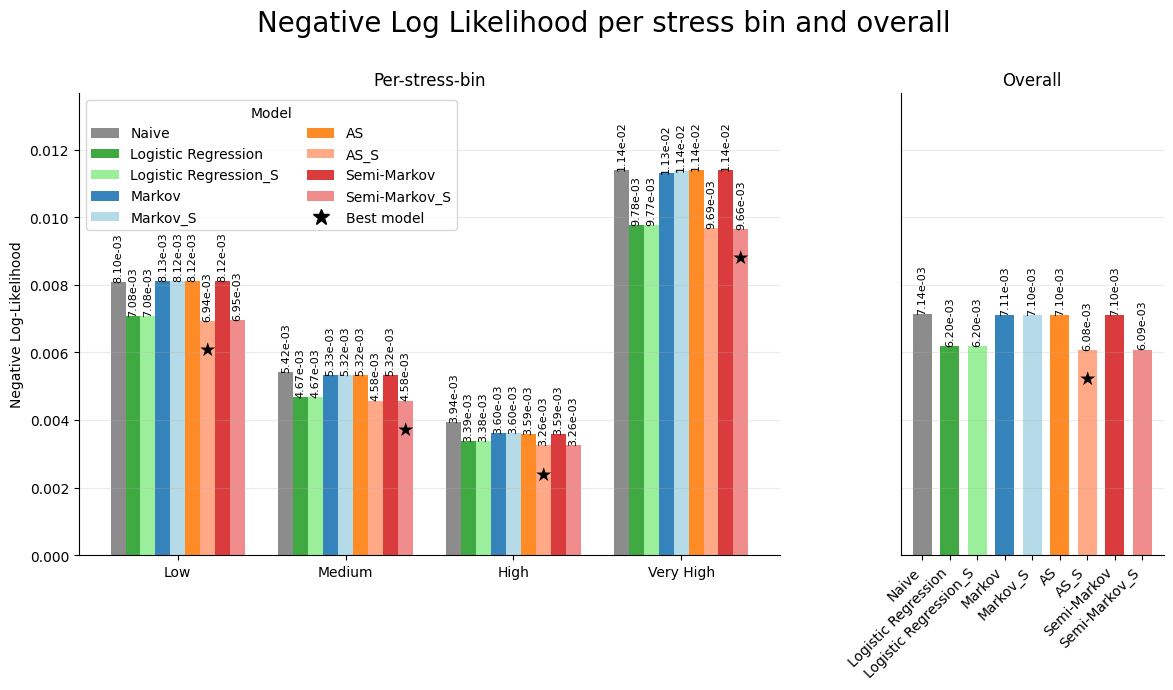

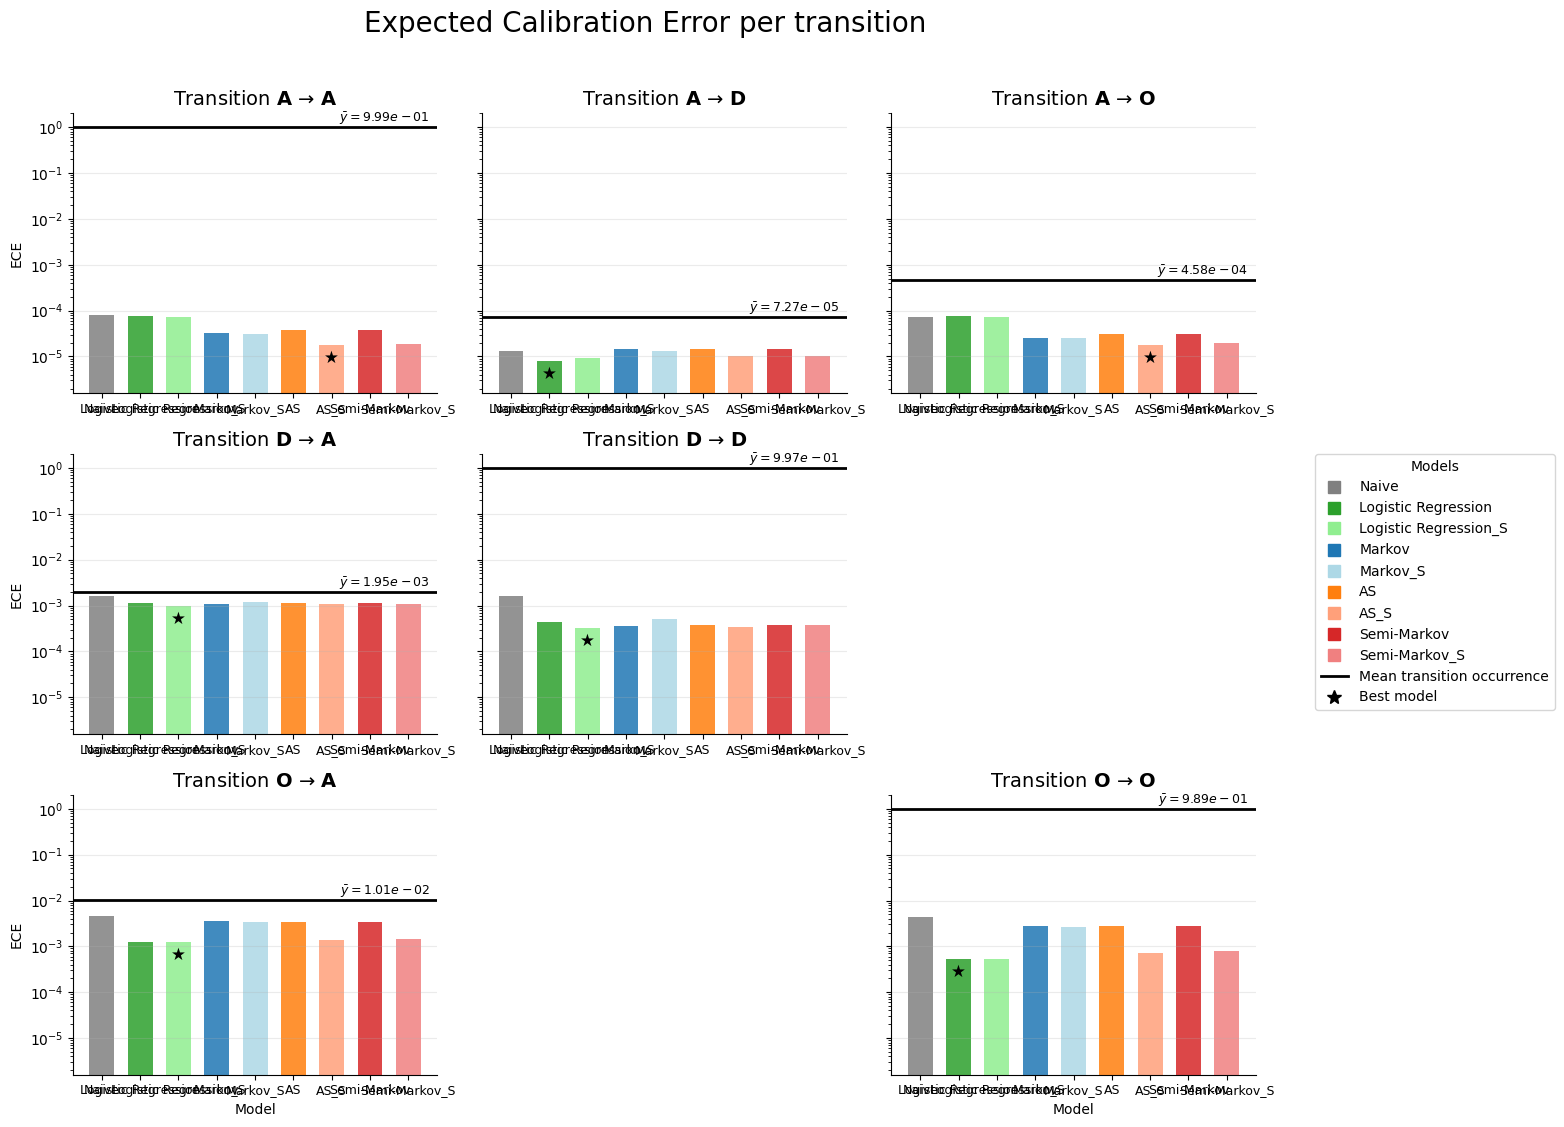

In [13]:
model_colors = {
    "Markov": "tab:blue",
    "Markov_S": "lightblue",
    "Naive": "gray",
    "Semi-Markov": "tab:red",
    "Semi-Markov_S": "lightcoral",
    "AS": "tab:orange",
    "AS_S": "lightsalmon",
    "Logistic Regression": "tab:green",
    "Logistic Regression_S": "lightgreen",
}

model_order = ["Naive", "Logistic Regression", "Logistic Regression_S", "Markov", "Markov_S", "AS", "AS_S", "Semi-Markov", "Semi-Markov_S"]

plot_nll_summary(
    nll_by_bin_df=nll_by_bin_df,
    nll_overall_df=nll_overall_df,
    model_order=model_order,
    model_colors=model_colors,
)

plot_ece_matrix(
    ece_df=ece_df,
    model_order=model_order,
    model_colors=model_colors,
)

# Further analysis

In [14]:
df_MC = model_results['Markov_S']
df_logreg = model_results['Logistic Regression_S']

In [15]:
df_MC['Stress'].describe()

count    1.577804e+06
mean     2.274965e+00
std      6.096313e-01
min      1.301105e-01
25%      1.875720e+00
50%      2.374180e+00
75%      2.754455e+00
max      5.339574e+00
Name: Stress, dtype: float64

In [16]:
df_logreg['Stress'].describe()

count    2.600597e+07
mean     2.314012e+00
std      6.243650e-01
min      1.301105e-01
25%      1.916550e+00
50%      2.411057e+00
75%      2.795936e+00
max      5.311088e+00
Name: Stress, dtype: float64

In [17]:
df_MC.drop_duplicates(subset=['Datetime_UTC', 'State'], inplace=True)
df_MC.reset_index(['Date']
df_logreg.drop_duplicates(subset=['Datetime_UTC', 'State'], inplace=True)
df_logreg.reset_index(drop=True, inplace=True)

SyntaxError: '(' was never closed (3301045709.py, line 2)

In [ ]:
df_merged = df_MC.merge(df_logreg, on=['Datetime_UTC', 'State'], suffixes=('_MC', '_LogReg'), validate='one_to_one')

In [ ]:
df_merged['Stress_MC']-df_merged['Stress_LogReg']

0         0.000000
1         0.000000
2         0.000096
3         0.000000
4        -0.030267
            ...   
801539    0.000000
801540    0.000071
801541    0.000000
801542    0.000000
801543    0.000000
Length: 801544, dtype: float64

In [ ]:
df_MC['Stress']

0         2.828461
1         2.844881
2         2.354635
3         2.350932
4         3.374772
            ...   
801539    2.183512
801540    2.464447
801541    1.692515
801542    2.315689
801543    2.358289
Name: Stress, Length: 801544, dtype: float64

In [ ]:
df_logreg['Stress']

0         2.796372
1         3.405039
2         2.960155
3         2.350932
4         2.828461
            ...   
801539    2.633529
801540    2.460972
801541    2.780811
801542    2.358289
801543    2.646278
Name: Stress, Length: 801544, dtype: float64

In [ ]:
(df_MC['Stress']==df_logreg['Stress']).all()

np.False_